## 1. Install dependencies

In [1]:
!pip install -q --upgrade wfdb scipy scikit-learn tensorflow matplotlib
print("Done.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.3/62.3 kB 4.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 6.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.3/35.3 MB 26.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 38.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.6/572.6 MB 895.0 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 75.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 69.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.0/11.0 MB 77.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 327.1/327.1 kB 19.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is th

## 2. Imports

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt

import wfdb
import tensorflow as tf
from tensorflow.keras import layers, models

from scipy.signal import butter, filtfilt, welch, detrend, find_peaks
from sklearn.model_selection import GroupShuffleSplit, GroupKFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import pearsonr

# Reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.21.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 3. Download the BIDMC dataset

This downloads all 53 records from PhysioNet the first time it runs (a few
hundred MB). If `dataset/` already has files in it, the download is skipped.

In [3]:
DATASET_DIR = "dataset"
PN_DIR = "bidmc"
BIDMC_RECORDS = [f"bidmc{str(i).zfill(2)}" for i in range(1, 54)]

os.makedirs(DATASET_DIR, exist_ok=True)

if len(os.listdir(DATASET_DIR)) == 0:
    print(f"Downloading {len(BIDMC_RECORDS)} BIDMC records from PhysioNet...")
    wfdb.dl_database(PN_DIR, dl_dir=DATASET_DIR)
    print("Download complete.")
else:
    print("Dataset already present, skipping download.")

print("Total records:", len(BIDMC_RECORDS))

Generating record list for: bidmc01
Generating record list for: bidmc02
Generating record list for: bidmc03
Generating record list for: bidmc04
Generating record list for: bidmc05
Generating record list for: bidmc06
Generating record list for: bidmc07
Generating record list for: bidmc08
Generating record list for: bidmc09
Generating record list for: bidmc10
Generating record list for: bidmc11
Generating record list for: bidmc12
Generating record list for: bidmc13
Generating record list for: bidmc14
Generating record list for: bidmc15
Generating record list for: bidmc16
Generating record list for: bidmc17
Generating record list for: bidmc18
Generating record list for: bidmc19
Generating record list for: bidmc20
Generating record list for: bidmc21
Generating record list for: bidmc22
Generating record list for: bidmc23
Generating record list for: bidmc24
Generating record list for: bidmc25
Generating record list for: bidmc26
Generating record list for: bidmc27
Generating record list for: 

## 4. Load a single record (sanity check)

Sampling frequency: 125
PPG length: 60001  Resp length: 60001


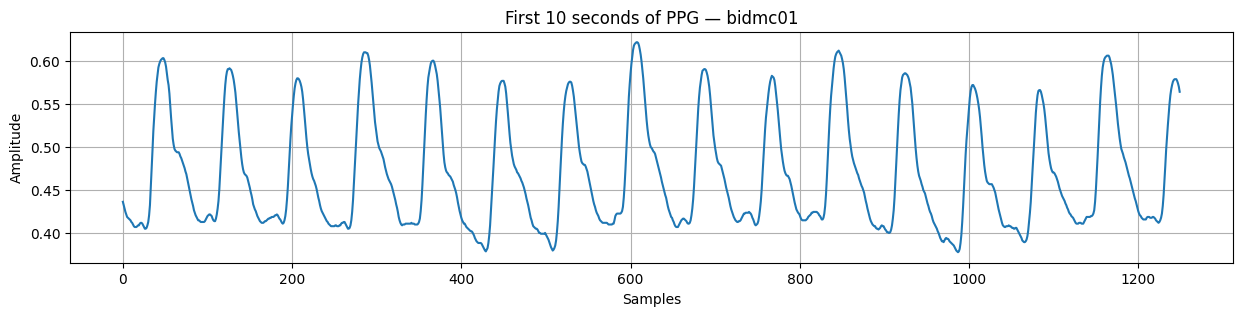

In [4]:
def load_record(record_name, dataset_dir=DATASET_DIR):
    """Load one BIDMC record. Returns (ppg, resp, fs)."""
    record_path = os.path.join(dataset_dir, record_name)
    record = wfdb.rdrecord(record_path)

    fs = record.fs
    sig_names = record.sig_name
    signals = record.p_signal

    def find_channel(keywords):
        for i, name in enumerate(sig_names):
            for kw in keywords:
                if kw.lower() in name.lower():
                    return i
        return None

    ppg_idx = find_channel(["pleth", "ppg"])
    resp_idx = find_channel(["resp", "impedance"])

    if ppg_idx is None or resp_idx is None:
        raise ValueError(f"Could not find PPG/RESP channels in {record_name}. "
                          f"Available channels: {sig_names}")

    ppg = signals[:, ppg_idx]
    resp = signals[:, resp_idx]
    return ppg, resp, fs


ppg, resp, fs = load_record(BIDMC_RECORDS[0])
print("Sampling frequency:", fs)
print("PPG length:", len(ppg), " Resp length:", len(resp))

plt.figure(figsize=(15, 3))
plt.plot(ppg[: fs * 10])
plt.title(f"First 10 seconds of PPG — {BIDMC_RECORDS[0]}")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.grid(True)
plt.show()

## 5. Preprocessing: bandpass filter + normalization

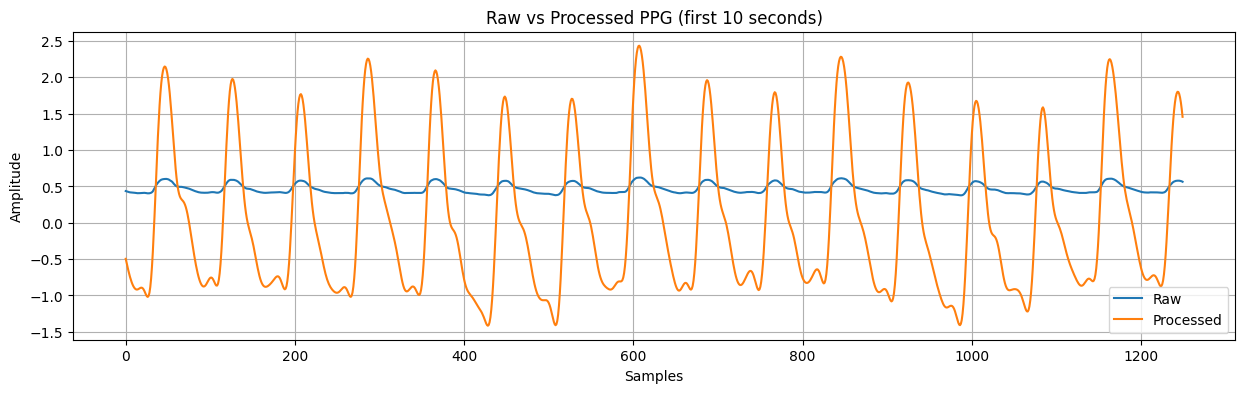

Processed mean: 5.1513489784444186e-18  std: 1.0


In [5]:
def bandpass_filter(signal, fs, lowcut=0.1, highcut=8.0, order=4):
    """Zero-phase Butterworth bandpass filter."""
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype="band")
    return filtfilt(b, a, signal)


def zscore_normalize(signal):
    """Zero-mean, unit-variance normalization."""
    mean = np.mean(signal)
    std = np.std(signal)
    if std < 1e-8:
        std = 1e-8
    return (signal - mean) / std


def preprocess_ppg(ppg_signal, fs, lowcut=0.1, highcut=8.0, order=4):
    """Bandpass filter -> detrend -> z-score normalize."""
    filtered = bandpass_filter(ppg_signal, fs, lowcut, highcut, order)
    filtered = detrend(filtered)
    normalized = zscore_normalize(filtered)
    return normalized


ppg_processed = preprocess_ppg(ppg, fs)

plt.figure(figsize=(15, 4))
plt.plot(ppg[: fs * 10], label="Raw")
plt.plot(ppg_processed[: fs * 10], label="Processed")
plt.title("Raw vs Processed PPG (first 10 seconds)")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.legend()
plt.grid(True)
plt.show()

print("Processed mean:", np.mean(ppg_processed), " std:", np.std(ppg_processed))

## 6. Segmentation: sliding windows

In [6]:
def segment_signal(signal, fs, window_sec=32, overlap=0.5):
    """Split `signal` into overlapping windows.

    Returns (windows, start_indices).
    """
    window_size = int(window_sec * fs)
    step = max(int(window_size * (1 - overlap)), 1)

    windows, start_indices = [], []
    for start in range(0, len(signal) - window_size + 1, step):
        end = start + window_size
        windows.append(signal[start:end])
        start_indices.append(start)

    return np.array(windows), np.array(start_indices)


WINDOW_SEC = 32
OVERLAP = 0.5

ppg_windows, start_idx = segment_signal(ppg_processed, fs, WINDOW_SEC, OVERLAP)
resp_windows, _ = segment_signal(resp, fs, WINDOW_SEC, OVERLAP)

print("Windows per record (example):", ppg_windows.shape)

Windows per record (example): (29, 4000)


## 7. Label generation: respiratory rate per window

RR is estimated from the respiration signal using the dominant frequency of
its power spectral density (Welch's method), restricted to a physiologically
plausible band (6–40 breaths/min). This is more robust to noisy peaks than
simple peak-counting, though a peak-counting fallback is included for
comparison/debugging.

In [7]:
def compute_rr_from_resp_fft(resp_window, fs, low_bpm=6, high_bpm=40):
    """Estimate RR (breaths/min) from the dominant PSD frequency."""
    resp_window = detrend(resp_window)
    n = len(resp_window)
    nfft = max(n * 8, 4096)  # zero-pad for finer frequency resolution

    freqs, psd = welch(resp_window, fs=fs, nperseg=n, nfft=nfft)

    low_hz, high_hz = low_bpm / 60.0, high_bpm / 60.0
    mask = (freqs >= low_hz) & (freqs <= high_hz)

    if not np.any(mask):
        return np.nan

    dominant_freq = freqs[mask][np.argmax(psd[mask])]
    return dominant_freq * 60.0


def compute_rr_from_resp_peaks(resp_window, fs, min_distance_sec=1.5):
    """Fallback / cross-check: estimate RR by counting peaks."""
    distance = max(int(min_distance_sec * fs), 1)
    peaks, _ = find_peaks(resp_window, distance=distance)
    duration_min = len(resp_window) / fs / 60.0
    return len(peaks) / duration_min if duration_min > 0 else np.nan


def generate_labels(resp_windows, fs, method="fft"):
    fn = compute_rr_from_resp_peaks if method == "peaks" else compute_rr_from_resp_fft
    return np.array([fn(w, fs) for w in resp_windows])


labels_fft = generate_labels(resp_windows, fs, method="fft")
labels_peaks = generate_labels(resp_windows, fs, method="peaks")

print("FFT-based labels (first 10):  ", np.round(labels_fft[:10], 2))
print("Peak-based labels (first 10): ", np.round(labels_peaks[:10], 2))
print("(These two methods should roughly agree — large disagreement on a "
      "given window is a sign of a noisy respiration signal.)")

FFT-based labels (first 10):   [23.67 22.73 21.09 20.62 22.03 23.2  21.56 20.16 22.03 21.09]
Peak-based labels (first 10):  [24.38 24.38 26.25 28.12 24.38 24.38 20.62 24.38 24.38 22.5 ]
(These two methods should roughly agree — large disagreement on a given window is a sign of a noisy respiration signal.)


## 8. Build the full dataset (all patients)

Loads every record, preprocesses, windows, and labels it. Windows with a
NaN label (no valid dominant frequency found) or with near-flat/likely-noisy
PPG are dropped. Each window is tagged with its patient ID so we can do
patient-wise splitting later.

In [8]:
def build_full_dataset(records, dataset_dir=DATASET_DIR, window_sec=WINDOW_SEC,
                        overlap=OVERLAP, label_method="fft", min_ppg_std=0.05):
    all_X, all_y, all_ids = [], [], []

    for rec in records:
        try:
            ppg_r, resp_r, fs_r = load_record(rec, dataset_dir)
        except Exception as e:
            print(f"Skipping {rec}: {e}")
            continue

        ppg_clean = preprocess_ppg(ppg_r, fs_r)

        ppg_w, _ = segment_signal(ppg_clean, fs_r, window_sec, overlap)
        resp_w, _ = segment_signal(resp_r, fs_r, window_sec, overlap)

        if len(ppg_w) == 0:
            continue

        y_w = generate_labels(resp_w, fs_r, method=label_method)

        # Drop windows with invalid labels or suspiciously flat PPG
        # (flat/near-constant PPG usually means a lead-off / artifact segment)
        raw_ppg_w, _ = segment_signal(ppg_r, fs_r, window_sec, overlap)
        ppg_std = raw_ppg_w.std(axis=1)
        valid = (~np.isnan(y_w)) & (ppg_std > min_ppg_std)

        if valid.sum() == 0:
            print(f"{rec}: no valid windows, skipping")
            continue

        all_X.append(ppg_w[valid])
        all_y.append(y_w[valid])
        all_ids.extend([rec] * valid.sum())

        print(f"{rec}: {valid.sum()} / {len(ppg_w)} usable windows")

    X = np.concatenate(all_X, axis=0)
    y = np.concatenate(all_y, axis=0)
    patient_ids = np.array(all_ids)
    return X, y, patient_ids


X, y, patient_ids = build_full_dataset(BIDMC_RECORDS)

print("\nFinal dataset:")
print("X shape:", X.shape)
print("y shape:", y.shape)
print("Unique patients:", len(np.unique(patient_ids)))

bidmc01: 29 / 29 usable windows
bidmc02: 29 / 29 usable windows
bidmc03: 29 / 29 usable windows
bidmc04: 29 / 29 usable windows
bidmc05: 29 / 29 usable windows
bidmc06: 29 / 29 usable windows
bidmc07: 29 / 29 usable windows
bidmc08: 29 / 29 usable windows
bidmc09: 29 / 29 usable windows
bidmc10: 29 / 29 usable windows
bidmc11: 29 / 29 usable windows
bidmc12: 29 / 29 usable windows
bidmc13: 29 / 29 usable windows
bidmc14: 29 / 29 usable windows
bidmc15: 29 / 29 usable windows
bidmc16: 29 / 29 usable windows
bidmc17: 29 / 29 usable windows
bidmc18: 29 / 29 usable windows
bidmc19: no valid windows, skipping
bidmc20: 29 / 29 usable windows
bidmc21: 29 / 29 usable windows
bidmc22: 29 / 29 usable windows
bidmc23: 29 / 29 usable windows
bidmc24: 29 / 29 usable windows
bidmc25: 29 / 29 usable windows
bidmc26: 29 / 29 usable windows
bidmc27: 29 / 29 usable windows
bidmc28: 29 / 29 usable windows
bidmc29: 29 / 29 usable windows
bidmc30: 29 / 29 usable windows
bidmc31: 29 / 29 usable windows
bidm

## 9. Inspect the label distribution

Always look at this before trusting the dataset. RR outside roughly
6–40 breaths/min is already excluded by the label function; here we check
for any remaining per-patient outliers that might indicate a noisy
respiration channel rather than genuine physiology.

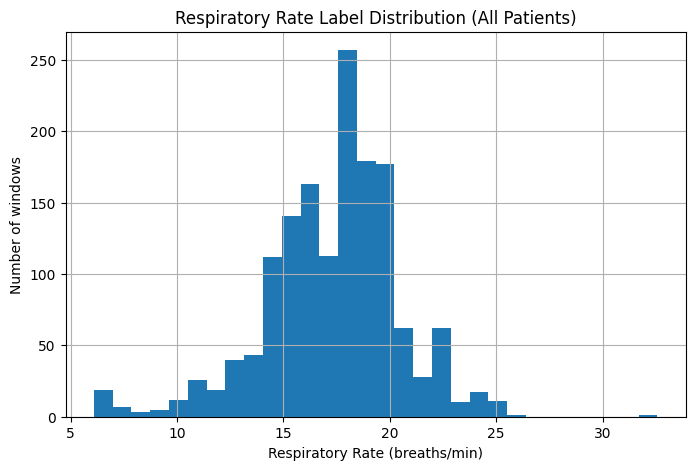

y range: [6.1, 32.6]  mean=17.3  std=3.2

Patients with unusual average RR (double-check their raw resp signal):
  bidmc05: mean RR = 7.8 bpm


In [9]:
plt.figure(figsize=(8, 5))
plt.hist(y, bins=30)
plt.xlabel("Respiratory Rate (breaths/min)")
plt.ylabel("Number of windows")
plt.title("Respiratory Rate Label Distribution (All Patients)")
plt.grid(True)
plt.show()

print(f"y range: [{y.min():.1f}, {y.max():.1f}]  mean={y.mean():.1f}  std={y.std():.1f}")

# Per-patient mean RR — flags any patient whose average looks physiologically
# implausible (e.g. far below ~10 or above ~30 bpm), worth a manual check.
unique_patients = np.unique(patient_ids)
patient_means = {p: y[patient_ids == p].mean() for p in unique_patients}
suspicious = {p: m for p, m in patient_means.items() if m < 10 or m > 30}
if suspicious:
    print("\nPatients with unusual average RR (double-check their raw resp signal):")
    for p, m in suspicious.items():
        print(f"  {p}: mean RR = {m:.1f} bpm")
else:
    print("\nNo patients with extreme average RR detected.")

## 10. Save the processed dataset

In [10]:
X_save = X.astype(np.float32)
y_save = y.astype(np.float32)

np.save("X.npy", X_save)
np.save("y.npy", y_save)
np.save("patient_ids.npy", patient_ids)

print("Saved X.npy, y.npy, patient_ids.npy")

# Optional: also save to Google Drive if running in Colab
try:
    from google.colab import drive
    drive.mount('/content/drive')
    save_path = "/content/drive/MyDrive/BIDMC_RR"
    os.makedirs(save_path, exist_ok=True)
    np.save(save_path + "/X.npy", X_save)
    np.save(save_path + "/y.npy", y_save)
    np.save(save_path + "/patient_ids.npy", patient_ids)
    print(f"Also saved to {save_path}")
except Exception:
    print("Not running in Colab (or Drive mount failed) — local .npy files are still saved.")

Saved X.npy, y.npy, patient_ids.npy
Mounted at /content/drive
Also saved to /content/drive/MyDrive/BIDMC_RR


## 11. Prepare CNN input + patient-wise train/val/test split

**This is the most important step for getting a trustworthy result.**
Windows are split by *patient*, not individually — so no patient appears in
more than one of train/val/test. This prevents the model from "cheating" by
recognizing a patient's pulse waveform rather than learning genuine
respiratory modulation.

In [11]:
X_cnn = X[..., np.newaxis]  # (n_windows, window_length, 1) for Conv1D
print("CNN input shape:", X_cnn.shape)

# ---- Train (70%) vs Temp (30%) ----
gss = GroupShuffleSplit(n_splits=1, test_size=0.30, random_state=SEED)
train_idx, temp_idx = next(gss.split(X_cnn, y, groups=patient_ids))

X_train, y_train = X_cnn[train_idx], y[train_idx]
X_temp, y_temp = X_cnn[temp_idx], y[temp_idx]
temp_groups = patient_ids[temp_idx]

# ---- Validation (15%) vs Test (15%) ----
gss2 = GroupShuffleSplit(n_splits=1, test_size=0.50, random_state=SEED)
val_idx, test_idx = next(gss2.split(X_temp, y_temp, groups=temp_groups))

X_val, y_val = X_temp[val_idx], y_temp[val_idx]
X_test, y_test = X_temp[test_idx], y_temp[test_idx]

print("Training:  ", X_train.shape)
print("Validation:", X_val.shape)
print("Testing:   ", X_test.shape)

# ---- Verify no patient leakage ----
train_patients = set(patient_ids[train_idx])
val_patients = set(temp_groups[val_idx])
test_patients = set(temp_groups[test_idx])

print("\nTrain patients:", len(train_patients))
print("Val patients:  ", len(val_patients))
print("Test patients: ", len(test_patients))
print("Train ∩ Val:  ", train_patients & val_patients)
print("Train ∩ Test: ", train_patients & test_patients)
print("Val ∩ Test:   ", val_patients & test_patients)
assert not (train_patients & val_patients)
assert not (train_patients & test_patients)
assert not (val_patients & test_patients)
print("\nNo patient leakage between splits — good.")

CNN input shape: (1508, 4000, 1)
Training:   (1044, 4000, 1)
Validation: (232, 4000, 1)
Testing:    (232, 4000, 1)

Train patients: 36
Val patients:   8
Test patients:  8
Train ∩ Val:   set()
Train ∩ Test:  set()
Val ∩ Test:    set()

No patient leakage between splits — good.


## 12. Normalize labels (using TRAIN statistics only)

Normalizing the target (RR) usually helps the network train more stably.
Critically, the mean/std used come **only from the training set** — using
val/test statistics here would leak information.

In [12]:
y_mean = np.mean(y_train)
y_std = np.std(y_train)

y_train_norm = (y_train - y_mean) / y_std
y_val_norm = (y_val - y_mean) / y_std
y_test_norm = (y_test - y_mean) / y_std   # kept for reference; we'll evaluate in real units

print(f"Train label mean: {y_mean:.3f}, std: {y_std:.3f}")
print(f"Normalized train mean/std: {np.mean(y_train_norm):.3f} / {np.std(y_train_norm):.3f}")

Train label mean: 17.318, std: 3.170
Normalized train mean/std: 0.000 / 1.000


## 13. Model: 1D CNN

A moderately sized architecture — enough capacity to learn waveform and
modulation features, but not so large that it can memorize individual
patients' pulse shapes given we only have ~37 training patients.

In [13]:
def build_cnn_model(input_length):
    inputs = layers.Input(shape=(input_length, 1), name="ppg_window")

    x = layers.Conv1D(32, kernel_size=7, padding="same")(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.MaxPooling1D(pool_size=2)(x)
    x = layers.Dropout(0.2)(x)

    x = layers.Conv1D(64, kernel_size=5, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.MaxPooling1D(pool_size=2)(x)
    x = layers.Dropout(0.3)(x)

    x = layers.Conv1D(128, kernel_size=3, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(64, activation="relu")(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(1, activation="linear", name="rr_bpm")(x)

    return models.Model(inputs, outputs, name="ppg_rr_cnn")


model = build_cnn_model(X_train.shape[1])
model.summary()

Model: "ppg_rr_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ ppg_window (InputLayer)         │ (None, 4000, 1)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 4000, 32)       │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 4000, 32)       │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 4000, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 2000, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2000, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 2000, 64)       │        10,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 2000, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 2000, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 1000, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1000, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 1000, 128)      │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 1000, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 1000, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rr_bpm (Dense)                  │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 44,481 (173.75 KB)

 Trainable params: 44,033 (172.00 KB)

 Non-trainable params: 448 (1.75 KB)

## 14. Compile and train

Key robustness choices versus a naive setup:
- **Huber loss** instead of MSE — much less sensitive to the occasional
  outlier RR label, which previously caused validation-loss spikes.
- **Gradient clipping** (`clipnorm=1.0`) — further guards against unstable
  updates from any remaining outlier batches.
- **`batch_size=32`** — more stable BatchNorm statistics than very small
  batches.
- **ReduceLROnPlateau + EarlyStopping** — automatically backs off the
  learning rate and stops once validation loss stops improving, restoring
  the best-performing weights.

In [14]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-4, clipnorm=1.0),
    loss=tf.keras.losses.Huber(delta=1.0),
    metrics=[tf.keras.metrics.MeanAbsoluteError(name="mae")]
)

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=15, restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.5, patience=6, min_lr=1e-6, verbose=1
    ),
    tf.keras.callbacks.ModelCheckpoint(
        "best_cnn.keras", monitor="val_loss", save_best_only=True
    ),
]

history = model.fit(
    X_train, y_train_norm,
    validation_data=(X_val, y_val_norm),
    epochs=150,
    batch_size=32,
    callbacks=callbacks,
    verbose=1,
)

Epoch 1/150
33/33 ━━━━━━━━━━━━━━━━━━━━ 26s 376ms/step - loss: 0.4281 - mae: 0.7890 - val_loss: 0.3382 - val_mae: 0.7236 - learning_rate: 5.0000e-04
Epoch 2/150
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.3981 - mae: 0.7525 - val_loss: 0.3625 - val_mae: 0.7594 - learning_rate: 5.0000e-04
Epoch 3/150
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.3893 - mae: 0.7394 - val_loss: 0.4172 - val_mae: 0.8358 - learning_rate: 5.0000e-04
Epoch 4/150
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.3808 - mae: 0.7300 - val_loss: 0.5075 - val_mae: 0.9542 - learning_rate: 5.0000e-04
Epoch 5/150
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.3732 - mae: 0.7196 - val_loss: 0.6188 - val_mae: 1.0850 - learning_rate: 5.0000e-04
Epoch 6/150
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.3744 - mae: 0.7249 - val_loss: 0.6859 - val_mae: 1.1573 - learning_rate: 5.0000e-04
Epoch 7/150
31/33 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.3797 - mae: 0.7294
Epoch 7: ReduceLROnPlateau reducing learn

## 15. Training curves

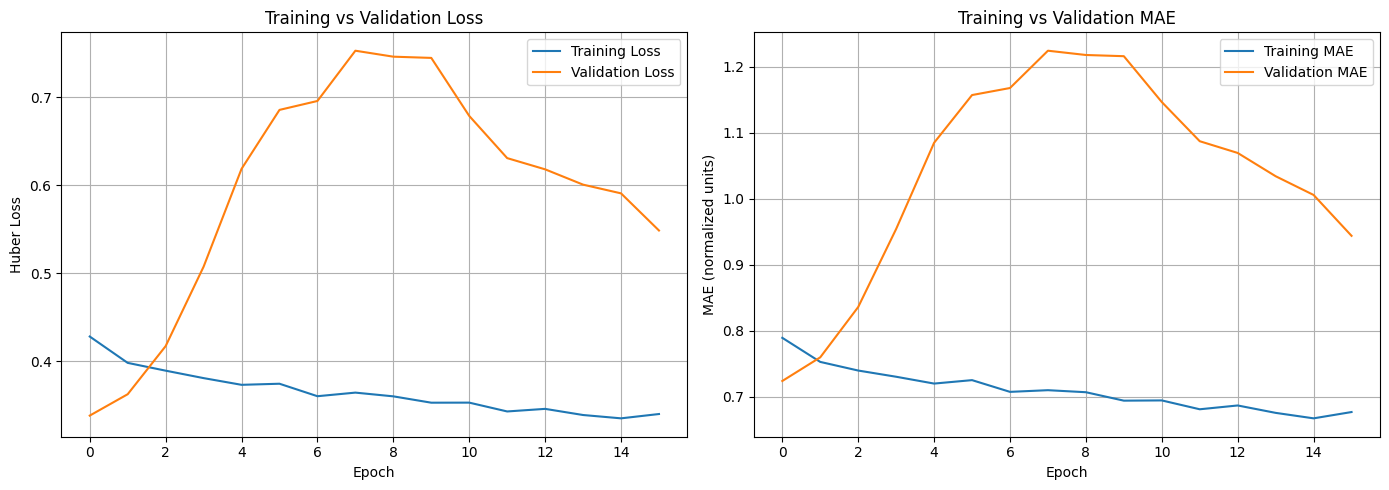

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history["loss"], label="Training Loss")
axes[0].plot(history.history["val_loss"], label="Validation Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Huber Loss")
axes[0].set_title("Training vs Validation Loss")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history.history["mae"], label="Training MAE")
axes[1].plot(history.history["val_mae"], label="Validation MAE")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("MAE (normalized units)")
axes[1].set_title("Training vs Validation MAE")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

## 16. Evaluate on the held-out test set

Predictions come out in **normalized** units (because we trained on
`y_train_norm`), so we de-normalize using the **training** mean/std before
computing metrics in real breaths/min.

In [16]:
y_pred_norm = model.predict(X_test).flatten()
y_pred = y_pred_norm * y_std + y_mean   # de-normalize back to breaths/min

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
corr, _ = pearsonr(y_test, y_pred)

print("Test set performance (held-out PATIENTS, not just windows):")
print(f"  MAE:       {mae:.3f} breaths/min")
print(f"  RMSE:      {rmse:.3f} breaths/min")
print(f"  R^2:       {r2:.3f}")
print(f"  Pearson r: {corr:.3f}")

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 96ms/step
Test set performance (held-out PATIENTS, not just windows):
  MAE:       2.453 breaths/min
  RMSE:      3.745 breaths/min
  R^2:       0.001
  Pearson r: 0.440


## 17. Visualize predictions

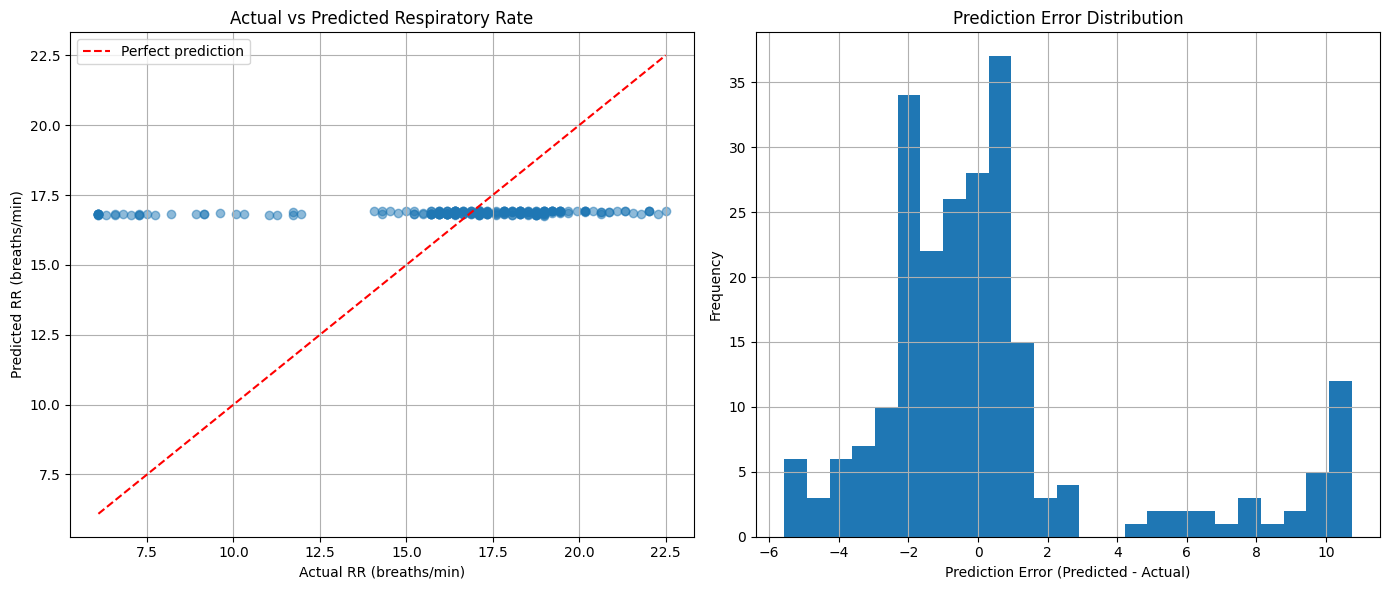

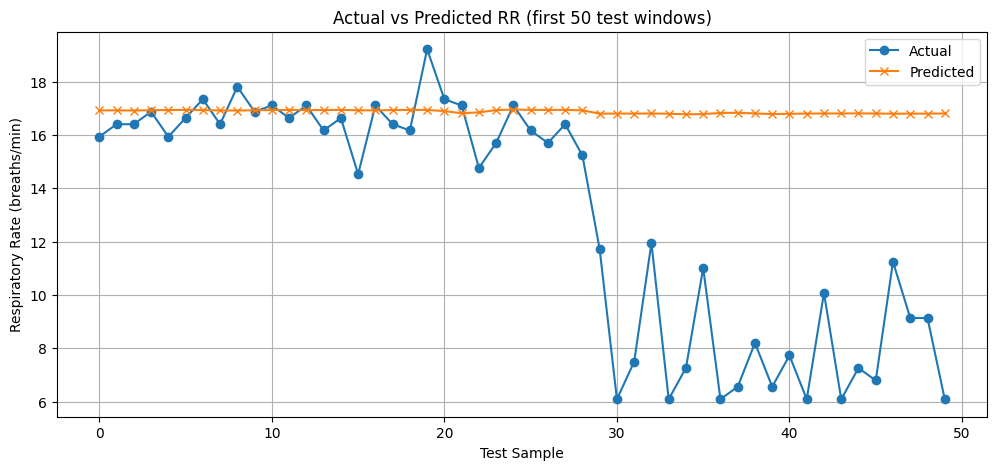

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].scatter(y_test, y_pred, alpha=0.5)
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
axes[0].plot(lims, lims, "r--", label="Perfect prediction")
axes[0].set_xlabel("Actual RR (breaths/min)")
axes[0].set_ylabel("Predicted RR (breaths/min)")
axes[0].set_title("Actual vs Predicted Respiratory Rate")
axes[0].legend()
axes[0].grid(True)

errors = y_pred - y_test
axes[1].hist(errors, bins=25)
axes[1].set_xlabel("Prediction Error (Predicted - Actual)")
axes[1].set_ylabel("Frequency")
axes[1].set_title("Prediction Error Distribution")
axes[1].grid(True)

plt.tight_layout()
plt.show()

n_show = min(50, len(y_test))
plt.figure(figsize=(12, 5))
plt.plot(y_test[:n_show], label="Actual", marker="o")
plt.plot(y_pred[:n_show], label="Predicted", marker="x")
plt.xlabel("Test Sample")
plt.ylabel("Respiratory Rate (breaths/min)")
plt.title(f"Actual vs Predicted RR (first {n_show} test windows)")
plt.legend()
plt.grid(True)
plt.show()

## 18. Patient-grouped K-fold cross-validation

A single train/val/test split is noisy when there are only ~53 patients —
one unlucky test patient can swing R² a lot. This repeats training across
multiple patient-grouped folds so we get a much more honest estimate of
real-world performance (mean ± std across folds), and it directly tells us
whether the single-split result above was representative or a fluke.

This step retrains the model several times, so it will take a while
(roughly `n_splits` × the single training run above).

In [18]:
N_SPLITS = 5  # ~10-11 patients held out per fold
gkf = GroupKFold(n_splits=N_SPLITS)

fold_results = []

for fold, (tr_idx, te_idx) in enumerate(gkf.split(X_cnn, y, groups=patient_ids)):
    X_tr, y_tr = X_cnn[tr_idx], y[tr_idx]
    X_te, y_te = X_cnn[te_idx], y[te_idx]

    y_mean_f, y_std_f = y_tr.mean(), y_tr.std()
    y_tr_norm = (y_tr - y_mean_f) / y_std_f

    fold_model = build_cnn_model(X_tr.shape[1])
    fold_model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=5e-4, clipnorm=1.0),
        loss=tf.keras.losses.Huber(delta=1.0),
        metrics=["mae"],
    )

    fold_model.fit(
        X_tr, y_tr_norm,
        validation_split=0.15,
        epochs=100,
        batch_size=32,
        callbacks=[
            tf.keras.callbacks.EarlyStopping(
                monitor="val_loss", patience=12, restore_best_weights=True
            ),
            tf.keras.callbacks.ReduceLROnPlateau(
                monitor="val_loss", factor=0.5, patience=5, min_lr=1e-6
            ),
        ],
        verbose=0,
    )

    y_pred_f_norm = fold_model.predict(X_te, verbose=0).flatten()
    y_pred_f = y_pred_f_norm * y_std_f + y_mean_f

    fold_mae = mean_absolute_error(y_te, y_pred_f)
    fold_rmse = np.sqrt(mean_squared_error(y_te, y_pred_f))
    fold_r2 = r2_score(y_te, y_pred_f)
    fold_corr, _ = pearsonr(y_te, y_pred_f)

    fold_results.append(dict(mae=fold_mae, rmse=fold_rmse, r2=fold_r2, pearson_r=fold_corr))
    print(f"Fold {fold+1}/{N_SPLITS}: MAE={fold_mae:.2f}  RMSE={fold_rmse:.2f}  "
          f"R2={fold_r2:.3f}  r={fold_corr:.3f}  (n_test_windows={len(y_te)})")

maes = [r["mae"] for r in fold_results]
rmses = [r["rmse"] for r in fold_results]
r2s = [r["r2"] for r in fold_results]
corrs = [r["pearson_r"] for r in fold_results]

print("\n=== Cross-validated performance (patient-grouped, mean ± std) ===")
print(f"MAE:       {np.mean(maes):.3f} ± {np.std(maes):.3f} breaths/min")
print(f"RMSE:      {np.mean(rmses):.3f} ± {np.std(rmses):.3f} breaths/min")
print(f"R^2:       {np.mean(r2s):.3f} ± {np.std(r2s):.3f}")
print(f"Pearson r: {np.mean(corrs):.3f} ± {np.std(corrs):.3f}")
print("\nIf fold results vary a lot, that's expected with only ~53 patients — "
      "the mean/std above is the trustworthy summary, not any single fold.")

Fold 1/5: MAE=1.90  RMSE=2.32  R2=0.018  r=0.374  (n_test_windows=319)
Fold 2/5: MAE=3.49  RMSE=4.14  R2=-0.298  r=-0.200  (n_test_windows=319)
Fold 3/5: MAE=2.90  RMSE=4.06  R2=-0.111  r=0.253  (n_test_windows=290)
Fold 4/5: MAE=2.08  RMSE=2.53  R2=-0.195  r=0.438  (n_test_windows=290)
Fold 5/5: MAE=2.11  RMSE=2.74  R2=-0.178  r=0.329  (n_test_windows=290)

=== Cross-validated performance (patient-grouped, mean ± std) ===
MAE:       2.495 ± 0.606 breaths/min
RMSE:      3.156 ± 0.781 breaths/min
R^2:       -0.153 ± 0.104
Pearson r: 0.239 ± 0.227

If fold results vary a lot, that's expected with only ~53 patients — the mean/std above is the trustworthy summary, not any single fold.


## 19. Save the final model and predictions

In [19]:
model.save("rr_cnn_model.keras")
np.save("y_test_actual.npy", y_test)
np.save("y_test_predicted.npy", y_pred)

print("Saved rr_cnn_model.keras, y_test_actual.npy, y_test_predicted.npy")

Saved rr_cnn_model.keras, y_test_actual.npy, y_test_predicted.npy
